# Super-Resolution Exercises

## Exercise 1: Basic Upsampling Techniques

**Objective:** Implement and compare basic upsampling techniques using opencv.

**Tasks:**
1. Load an image.
2. Downsample the image.
3. Apply various upsampling techniques.
4. Display the results.
5. Save the results.

**Code**

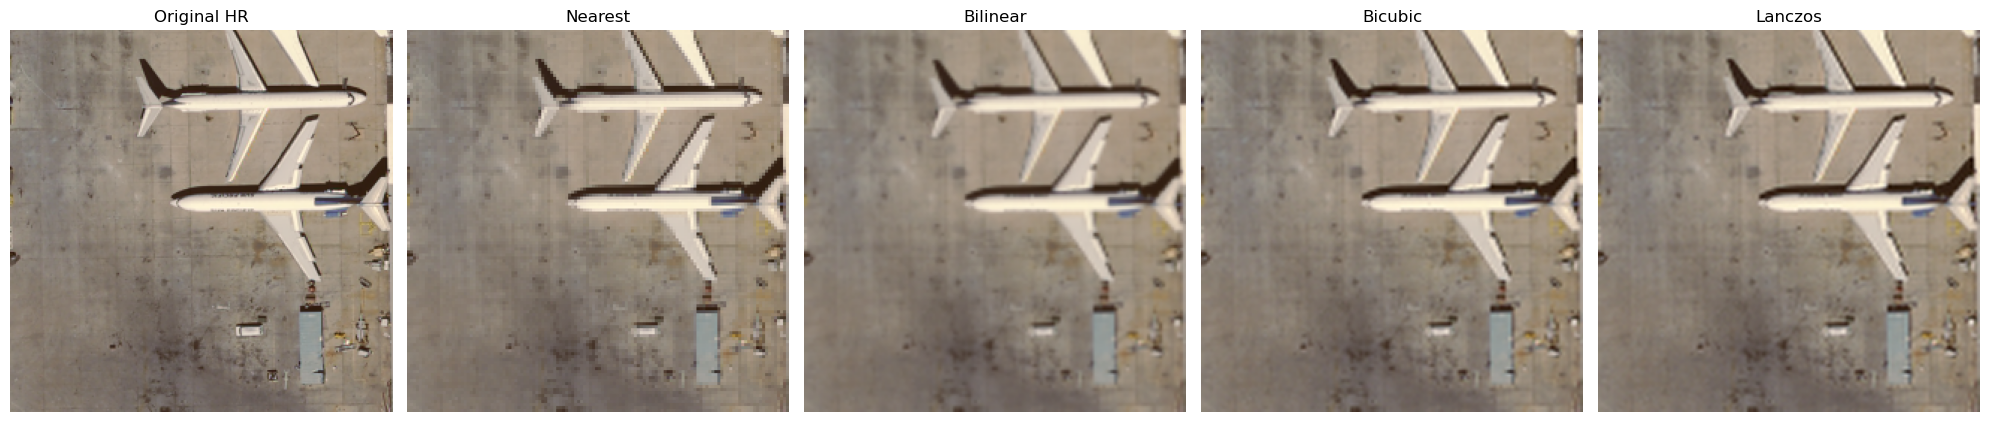

True

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. LOAD THE IMAGE
image_hr = cv2.imread('./images/image_hr.png')  # Load image in BGR
image_hr = cv2.cvtColor(image_hr, cv2.COLOR_BGR2RGB)  # Convert to RGB

# 2. DOWNSAMPLE THE IMAGE
scale_factor = 0.5
image_lr = cv2.resize(image_hr, (0, 0), fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)

# 3. UPSAMPLE USING DIFFERENT METHODS
height, width = image_hr.shape[:2]
upsampled_nearest = cv2.resize(image_lr, (width, height), interpolation=cv2.INTER_NEAREST)
upsampled_bilinear = cv2.resize(image_lr, (width, height), interpolation=cv2.INTER_LINEAR)
upsampled_bicubic = cv2.resize(image_lr, (width, height), interpolation=cv2.INTER_CUBIC)
upsampled_lanczos = cv2.resize(image_lr, (width, height), interpolation=cv2.INTER_LANCZOS4)

# 4. DISPLAY RESULTS
titles = ['Original HR', 'Nearest', 'Bilinear', 'Bicubic', 'Lanczos']
images = [image_hr, upsampled_nearest, upsampled_bilinear, upsampled_bicubic, upsampled_lanczos]

fig, axs = plt.subplots(1, 5, figsize=(20, 5))
for i in range(5):
    axs[i].imshow(images[i])
    axs[i].set_title(titles[i])
    axs[i].axis('off')
plt.tight_layout()
plt.show()

# 5. SAVE RESULTS
output_dir = './outputs_upsampling'
os.makedirs(output_dir, exist_ok=True)

cv2.imwrite(os.path.join(output_dir, 'nearest.png'), cv2.cvtColor(upsampled_nearest, cv2.COLOR_RGB2BGR))
cv2.imwrite(os.path.join(output_dir, 'bilinear.png'), cv2.cvtColor(upsampled_bilinear, cv2.COLOR_RGB2BGR))
cv2.imwrite(os.path.join(output_dir, 'bicubic.png'), cv2.cvtColor(upsampled_bicubic, cv2.COLOR_RGB2BGR))
cv2.imwrite(os.path.join(output_dir, 'lanczos.png'), cv2.cvtColor(upsampled_lanczos, cv2.COLOR_RGB2BGR))


## Exercise 2: Compute PSNR and SSIM

**Objective:** Compute PSNR and SSIM for comparing image quality.

**Tasks:**
1. Implement functions to compute PSNR and SSIM.
2. Load the previous image saved.
3. Evaluate these metrics for different upsampling methods.

In [5]:
import cv2
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os

# 1. IMPLEMENT FUNCTIONS TO COMPUTE PSNR AND SSIM
def compute_metrics(img1, img2):
    """Compute PSNR and SSIM between two RGB images."""
    psnr_value = psnr(img1, img2, data_range=255)
    ssim_value = ssim(img1, img2, channel_axis=-1, data_range=255)
    return psnr_value, ssim_value

# 2. LOAD THE ORIGINAL AND UPSAMPLED IMAGES
def load_image(path):
    """Read an image and convert it to RGB"""
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Paths
base_dir = './outputs_upsampling'
image_hr = load_image('./images/image_hr.png')
methods = ['nearest', 'bilinear', 'bicubic', 'lanczos']

# 3. EVALUATE METRICS
for method in methods:
    image_up = load_image(os.path.join(base_dir, f'{method}.png'))
    psnr_val, ssim_val = compute_metrics(image_hr, image_up)
    print(f"{method.upper():<10} | PSNR: {psnr_val:.2f} dB | SSIM: {ssim_val:.4f}")

NEAREST    | PSNR: 28.54 dB | SSIM: 0.8916
BILINEAR   | PSNR: 29.12 dB | SSIM: 0.8863
BICUBIC    | PSNR: 30.35 dB | SSIM: 0.9113
LANCZOS    | PSNR: 30.47 dB | SSIM: 0.9122
